### Problem Statement

You are a data scientist / AI engineer working on a classification problem to predict the likelihood of pet adoption. You have been provided with a dataset named **`"pet_adoption.csv"`**, which includes various parameters that affect the likelihood of pet adoption. The dataset comprises the following columns:

- `pet_id:` Unique identifier for each pet.
- `pet_type:` Type of pet (e.g., Dog, Cat, Bird, Rabbit).
- `breed:` Specific breed of the pet.
- `age_months:` Age of the pet in months.
- `color:` Color of the pet.
- `size:` Size category of the pet (Small, Medium, Large).
- `weight_kg:` Weight of the pet in kilograms.
- `vaccinated:` Vaccination status of the pet (0 - Not vaccinated, 1 - Vaccinated).
- `health_condition:` Health condition of the pet (0 - Healthy, 1 - Medical condition).
- `timein_shelter_days:` Duration the pet has been in the shelter (days).
- `adoption_fee:` Adoption fee charged for the pet (in dollars).
- `previous_owner:` Whether the pet had a previous owner (0 - No, 1 - Yes).
- `adoption_likelihood:` Likelihood of the pet being adopted (0 - Unlikely, 1 - Likely).

Your task is to use this dataset to build and evaluate machine learning models to predict the likelihood of pet adoption based on the given parameters. You will perform data preprocessing, exploratory data analysis, and model training using a Decision Tree algorithm.

**Dataset credits:** Rabie El Kharoua (https://www.kaggle.com/datasets/rabieelkharoua/predict-pet-adoption-status-dataset)

**Import Necessary Libraries**

In [24]:
# Import Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text

### Task 1: Data Preparation and Exploration

1. Import the data from the `"pet_adoption_data.csv"` file and store it in a variable df.
2. Display the number of rows and columns in the dataset.
3. Display the first few rows of the dataset to get an overview.
4. Drop the columns that do not add much value to the analysis `('pet_id')`.
5. Visualize the distribution of the target variable 'adoption_likelihood' using a bar chart.
6. Visualize the distribution of 'age_months' and 'adoption_fee' using histograms.

In [4]:
# Step 1: Import the data from the "pet_adoption.csv" file
df = pd.read_csv("pet_adoption_data.csv")

# Step 2: Display the number of rows and columns in the dataset
print(df.shape)

# Step 3: Display the first few rows of the dataset to get an overview
df.head(10)

(2007, 13)


,pet_id,pet_type,breed,age_months,color,size,weight_kg,vaccinated,health_condition,timein_shelter_days,adoption_fee,previous_owner,adoption_likelihood
0,500,Bird,Parakeet,131,Orange,Large,5.039768,1,0,27,140,0,0
1,501,Rabbit,Rabbit,73,White,Large,16.086727,0,0,8,235,0,0
2,502,Dog,Golden Retriever,136,Orange,Medium,2.076286,0,0,85,385,0,0
3,503,Bird,Parakeet,97,White,Small,3.339423,0,0,61,217,1,0
4,504,Rabbit,Rabbit,123,Gray,Large,20.498100,0,0,28,14,1,0
5,505,Dog,Labrador,70,Brown,Large,20.986261,0,0,87,301,1,0
6,506,Bird,Parakeet,169,Brown,Small,10.902613,1,0,70,440,1,0
7,507,Cat,Siamese,13,Orange,Large,7.252683,1,0,3,137,0,1
8,508,Bird,Parakeet,49,Brown,Medium,24.597598,1,1,69,405,0,0
9,509,Bird,Parakeet,60,Gray,Large,7.295994,0,0,73,231,1,0


In [5]:
# Step 4: Drop the columns that do not add much value to the analysis
df.drop(columns=['pet_id'], inplace=True)
df.head()

,pet_type,breed,age_months,color,size,weight_kg,vaccinated,health_condition,timein_shelter_days,adoption_fee,previous_owner,adoption_likelihood
0,Bird,Parakeet,131,Orange,Large,5.039768,1,0,27,140,0,0
1,Rabbit,Rabbit,73,White,Large,16.086727,0,0,8,235,0,0
2,Dog,Golden Retriever,136,Orange,Medium,2.076286,0,0,85,385,0,0
3,Bird,Parakeet,97,White,Small,3.339423,0,0,61,217,1,0
4,Rabbit,Rabbit,123,Gray,Large,20.498100,0,0,28,14,1,0


/tmp/ipykernel_35627/1786779143.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="adoption_likelihood", data=df, palette="Set2")
/tmp/ipykernel_35627/1786779143.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Unlikely (0)", "Likely (1)"])


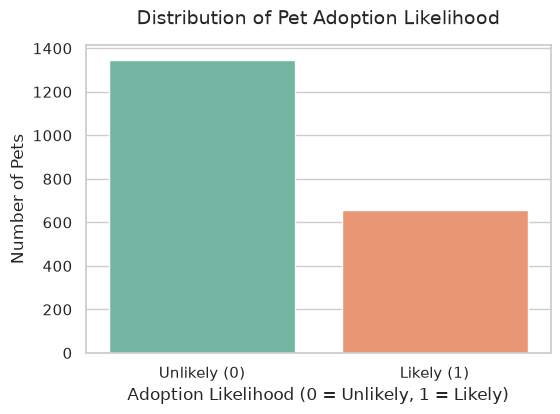

In [6]:
# Step 5: Visualize the distribution of the target variable 'adoption_likelihood' using a bar chart

# 1. Set the visual style and figure size
sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 4))

# 2. Create the bar chart using countplot
# 'data=df_cleaned' assumes you are using the DataFrame from Step 4
ax = sns.countplot(x="adoption_likelihood", data=df, palette="Set2")

# 3. Add clean labels and a title
plt.title("Distribution of Pet Adoption Likelihood", fontsize=14, pad=15)
plt.xlabel("Adoption Likelihood (0 = Unlikely, 1 = Likely)", fontsize=12)
plt.ylabel("Number of Pets", fontsize=12)

# 4. Change the x-axis tick labels to be human-readable
ax.set_xticklabels(["Unlikely (0)", "Likely (1)"])

# 5. Display the plot
plt.show()


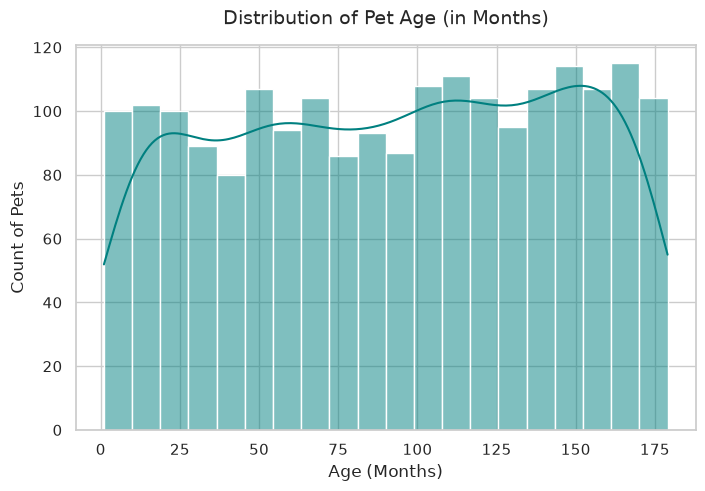

In [7]:
# Step 6: Visualize the distribution of 'age_months' using a histogram
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="age_months",
    kde=True,
    color="teal",
    bins=20,
)

# 3. Add clean labels and a title
plt.title("Distribution of Pet Age (in Months)", fontsize=14, pad=15)
plt.xlabel("Age (Months)", fontsize=12)
plt.ylabel("Count of Pets", fontsize=12)

# 4. Display the plot
plt.show()

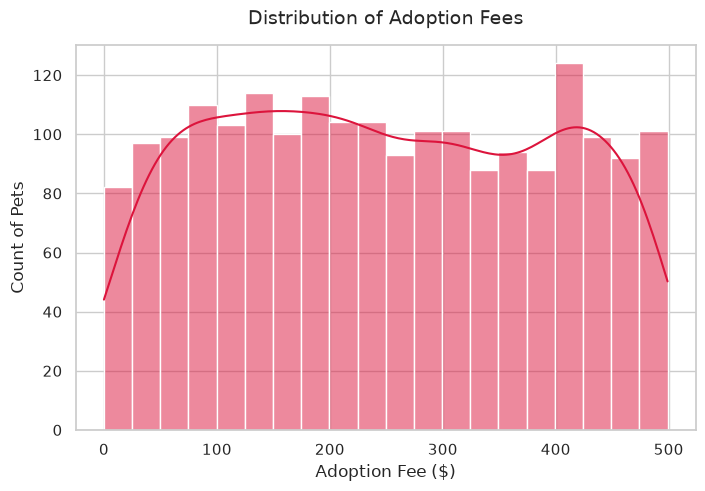

In [8]:
# Step 7: Visualize the distribution of 'adoption_fee' using a histogram
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# 2. Create the histogram for adoption_fee
sns.histplot(
    data=df,
    x="adoption_fee",
    kde=True,
    color="crimson",  # Changed color to distinguish from age
    bins=20,          # Groups the fees into 20 clean intervals
)

# 3. Add clean labels and a title
plt.title("Distribution of Adoption Fees", fontsize=14, pad=15)
plt.xlabel("Adoption Fee ($)", fontsize=12)
plt.ylabel("Count of Pets", fontsize=12)

# 4. Display the plot
plt.show()

### Task 2: Data Encoding and Scaling

1. Encode the categorical variables:
    - `'size'`: Encode by mapping it to numbers (e.g., Small=1, Medium=2, Large=3).
    - `'color'`, `'pet_type'`, `'breed'`: Apply one-hot encoding.
<br></br>
3. Scale the numerical features:
    - `'weight_kg'`: MinMax scaling.
    - `'adoption_fee'`: Standard scaling.
<br></br>
4. Display the first few rows of the updated dataset.

In [9]:
# Step 1: Encode the categorical variables

# Encode 'size' by mapping it to numbers (e.g., Small=1, Medium=2, Large=3).
df['size'] = df['size'].map({"Small": 1, "Medium": 2, "Large": 3})
# Encode 'color', 'pet_type' and 'breed' using one-hot encoding
df = pd.get_dummies(df, columns=["color", "pet_type", "breed"], drop_first=True)

print(df.shape)
df.head()


(2007, 22)


,age_months,size,weight_kg,vaccinated,health_condition,timein_shelter_days,adoption_fee,previous_owner,adoption_likelihood,color_Brown,...,color_White,pet_type_Cat,pet_type_Dog,pet_type_Rabbit,breed_Labrador,breed_Parakeet,breed_Persian,breed_Poodle,breed_Rabbit,breed_Siamese
0,131,3,5.039768,1,0,27,140,0,0,False,...,False,False,False,False,False,True,False,False,False,False
1,73,3,16.086727,0,0,8,235,0,0,False,...,True,False,False,True,False,False,False,False,True,False
2,136,2,2.076286,0,0,85,385,0,0,False,...,False,False,True,False,False,False,False,False,False,False
3,97,1,3.339423,0,0,61,217,1,0,False,...,True,False,False,False,False,True,False,False,False,False
4,123,3,20.498100,0,0,28,14,1,0,False,...,False,False,False,True,False,False,False,False,True,False


In [10]:
# Step 2: Scale the numerical features

# Scale 'weight_kg' using MinMaxScaler
min_max_scaler = MinMaxScaler()
df['weight_kg'] = min_max_scaler.fit_transform(df[['weight_kg']])


# Scale 'adoption_fee' using StandardScaler
std_scaler = StandardScaler()
df['adoption_fee'] = std_scaler.fit_transform(df[['adoption_fee']])

df.head()

,age_months,size,weight_kg,vaccinated,health_condition,timein_shelter_days,adoption_fee,previous_owner,adoption_likelihood,color_Brown,...,color_White,pet_type_Cat,pet_type_Dog,pet_type_Rabbit,breed_Labrador,breed_Parakeet,breed_Persian,breed_Poodle,breed_Rabbit,breed_Siamese
0,131,3,0.138783,1,0,27,-0.764025,0,0,False,...,False,False,False,False,False,True,False,False,False,False
1,73,3,0.520009,0,0,8,-0.098998,0,0,False,...,True,False,False,True,False,False,False,False,True,False
2,136,2,0.036514,0,0,85,0.951044,0,0,False,...,False,False,True,False,False,False,False,False,False,False
3,97,1,0.080105,0,0,61,-0.225003,1,0,False,...,True,False,False,False,False,True,False,False,False,False
4,123,3,0.672244,0,0,28,-1.646060,1,0,False,...,False,False,False,True,False,False,False,False,True,False


In [11]:
# step3: Display the first few rows of the updated dataset.
df.head()


,age_months,size,weight_kg,vaccinated,health_condition,timein_shelter_days,adoption_fee,previous_owner,adoption_likelihood,color_Brown,...,color_White,pet_type_Cat,pet_type_Dog,pet_type_Rabbit,breed_Labrador,breed_Parakeet,breed_Persian,breed_Poodle,breed_Rabbit,breed_Siamese
0,131,3,0.138783,1,0,27,-0.764025,0,0,False,...,False,False,False,False,False,True,False,False,False,False
1,73,3,0.520009,0,0,8,-0.098998,0,0,False,...,True,False,False,True,False,False,False,False,True,False
2,136,2,0.036514,0,0,85,0.951044,0,0,False,...,False,False,True,False,False,False,False,False,False,False
3,97,1,0.080105,0,0,61,-0.225003,1,0,False,...,True,False,False,False,False,True,False,False,False,False
4,123,3,0.672244,0,0,28,-1.646060,1,0,False,...,False,False,False,True,False,False,False,False,True,False


### Task 3: Model Training Using Decision Tree

1. Select the features and the target variable `('adoption_likelihood')` for modeling.
2. Split the data into training and test sets with a test size of 30%.
3. Initialize and train a Decision Tree Classifier using the training data.
4. Print the model's accuracy score on the test data.
5. Make predictions on the test set.
6. Evaluate the model using a classification report and confusion matrix.
7. Visualize the confusion matrix.
8. Visualize the decision tree structure.

In [12]:
# Step 1: Select the features and the target variable for modeling
X = df.drop('adoption_likelihood', axis=1)
y = df['adoption_likelihood']


# Step 2: Split the data into training and test sets with a test size of 30%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [13]:
# Step 3: Initialize and train a Decision Tree Classifier using the training data
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# Step 4: Print the model's accuracy score on the test data
print("Accuarcy for the Model is: ", model.score(X_test, y_test))


Accuarcy for the Model is:  0.8706467661691543


In [14]:
# Step 5: Make predictions on the test set
y_test_pred = model.predict(X_test)
print(y_test_pred[:10])
print(y_test[:10].tolist())
# Step 6: Evaluate the model using a classification report and confusion matrix
report = classification_report(y_test, y_test_pred)
print(report)

[1 0 0 0 1 1 1 0 1 0]
[0, 0, 0, 0, 0, 1, 1, 0, 0, 0]
              precision    recall  f1-score   support

           0       0.92      0.88      0.90       403
           1       0.78      0.84      0.81       200

    accuracy                           0.87       603
   macro avg       0.85      0.86      0.86       603
weighted avg       0.87      0.87      0.87       603



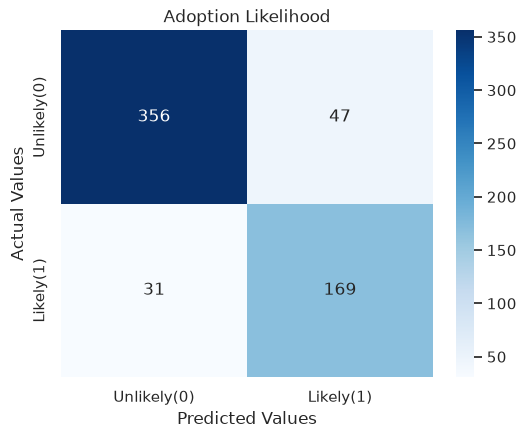

In [15]:
# Step 7: Visualize the confusion matrix
labels = ['Unlikely(0)', 'Likely(1)']
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 4.5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="Blues",
    xticklabels = labels,
    yticklabels = labels
)

plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("Adoption Likelihood")

plt.show()


### Task 4: Experiment with Hyperparameters in Decision Tree

1. Train the Decision Tree model with the following parameters:
   - criterion='entropy'
   - max_depth=5
   - min_samples_split=10
   - min_samples_leaf=5

Learn about these parameters here: [DecisionTreeClassifier Parameters](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)

--------------------------------------------------------------------------------------------------------------------------------------------------------


2. Print the model's accuracy score on the test data.
3. Evaluate the model using a classification report and confusion matrix.
4. Visualize the confusion matrix.
5. Visualize the decision tree structure.

In [16]:
# Step 1: Train the Decision Tree model with specified hyperparameters
model = DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_split=10, min_samples_leaf=5)
model.fit(X_train, y_train)

# Step 2: Print the model's accuracy score on the test data
print("Model Accuracy on Test Data: ", model.score(X_test, y_test))

# Step 3: Make predictions on the test set
y_test_pred_param = model.predict(X_test)
print(y_test_pred_param[:10])
print(y_test[:10].tolist())

# Step 4: Evaluate the model using a classification report and confusion matrix
report = classification_report(y_test, y_test_pred_param)
print(report)


Model Accuracy on Test Data:  0.9054726368159204
[1 0 0 0 0 1 1 0 0 0]
[0, 0, 0, 0, 0, 1, 1, 0, 0, 0]
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       403
           1       0.90      0.81      0.85       200

    accuracy                           0.91       603
   macro avg       0.90      0.88      0.89       603
weighted avg       0.91      0.91      0.90       603



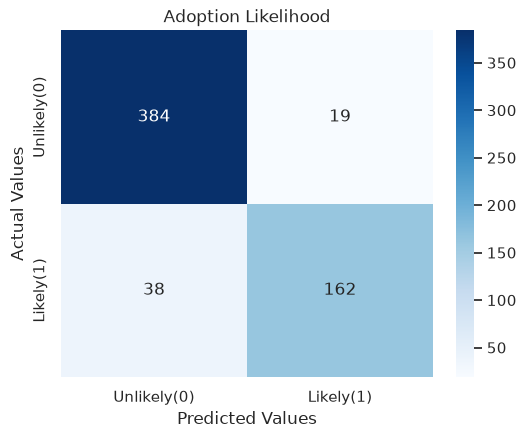

In [22]:
# Step 5: Visualize the confusion matrix
labels = ['Unlikely(0)', 'Likely(1)']
cm = confusion_matrix(y_test, y_test_pred_param)

plt.figure(figsize=(6, 4.5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("Adoption Likelihood")

plt.show()

In [25]:
# Step 6: Visualize the decision tree
print(export_text(model, feature_names = list(X.columns)))

|--- vaccinated <= 0.50
|   |--- age_months <= 34.50
|   |   |--- size <= 1.50
|   |   |   |--- color_White <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- color_White >  0.50
|   |   |   |   |--- class: 0
|   |   |--- size >  1.50
|   |   |   |--- size <= 2.50
|   |   |   |   |--- age_months <= 23.00
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- age_months >  23.00
|   |   |   |   |   |--- class: 0
|   |   |   |--- size >  2.50
|   |   |   |   |--- adoption_fee <= -0.49
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- adoption_fee >  -0.49
|   |   |   |   |   |--- class: 0
|   |--- age_months >  34.50
|   |   |--- pet_type_Dog <= 0.50
|   |   |   |--- timein_shelter_days <= 34.50
|   |   |   |   |--- class: 0
|   |   |   |--- timein_shelter_days >  34.50
|   |   |   |   |--- color_Brown <= 0.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- color_Brown >  0.50
|   |   |   |   |   |--- class: 0
|   |   |--- pet_type_Dog >  0.50
|   |   |   |--- size <= 2.5